# Model Classifier for 5 Risks

#### **ALY6130 Risk Management Analytics - Assignment 4**

#### **Case Study: EQB Inc. / PC Financial Acquisition**

#### **Presented to: Professor Abeba Nigussie Turi**

#### **Group 2: Md Maniur Rahman, Rahul Reddy Basani, Shanmugapriya G**

#### **Date: 18-03-2026**

### Problem Statement

Building on Assignment 3  where 40 risks were identified, scored, and classified using the  Likelihood x Impact scale and a Random Forest classifier was built as an extra step

However, Assignment 4 applies quantitative I&W analysis to the five highest-priority risks selected for deeper assessment.

This notebook is almost a replica of the Random Forest classification model from Assignment 3, applied specifically to the five selected risks. The model validates that the I&W risk selection is consistent with the ML-predicted priority classifications, providing a quantitative bridge between the qualitative risk register and the quantitative assessment.

**Five risks assessed:**
- R-01: Cybersecurity Breach During IT Integration (L=9, I=9, Score=81)
- R-02: Regulatory Approval Delay (L=3, I=8, Score=24)
- R-03: Customer Attrition from PC Financial Portfolio (L=7, I=8, Score=56)
- R-04: Fraud Spike During Integration (L=9, I=6, Score=54)
- R-05: Cross-Sell Conversion Opportunity — Positive Risk (L=9, I=9, Score=81)

In [1]:
%matplotlib inline

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


### Risk Data - Five Selected Risks

The five risks are defined directly using their Likelihood Score, Impact Score, and Risk Score from the Assignment 3 register -values are hardcoded

Priority thresholds follow the scoring scale:
- **High:** Risk Score >= 45
- **Medium:** Risk Score 21–44
- **Low:** Risk Score <= 20

In [2]:
# Define the five selected risks directly
# Values taken from the Assignment 3 verified risk register

data = {
    'Risk_ID': ['R-01', 'R-02', 'R-03', 'R-04', 'R-05'],
    'Risk_Description': [
        'Cybersecurity breach during IT system integration',
        'Regulatory approval delay by OSFI / Minister of Finance',
        'Customer attrition from PC Financial portfolio during brand transition',
        'Fraud spike during integration — account takeover and identity fraud',
        'Cross-sell conversion opportunity — PC Financial credit-card customers'
    ],
    'Likelihood_Score': [9, 3, 7, 9, 9],
    'Impact_Score':     [9, 8, 8, 6, 9],
    'Risk_Type': ['Threat', 'Threat', 'Threat', 'Threat', 'Opportunity']
}

risk_df = pd.DataFrame(data)

# Compute Risk Score (Likelihood x Impact) using course scoring scale
risk_df['Risk_Score'] = risk_df['Likelihood_Score'] * risk_df['Impact_Score']

# Define severity label based on course thresholds
# High >= 45 | Medium 21-44 | Low <= 20
def classify_severity(row):
    if row['Risk_Score'] >= 45:
        return 'High'
    elif row['Risk_Score'] >= 21:
        return 'Medium'
    else:
        return 'Low'

# Apply function to classify severity
risk_df['Severity_Label'] = risk_df.apply(classify_severity, axis=1)

# View the risk data
risk_df

,Risk_ID,Risk_Description,Likelihood_Score,Impact_Score,Risk_Type,Risk_Score,Severity_Label
0,R-01,Cybersecurity breach during IT system integration,9,9,Threat,81,High
1,R-02,Regulatory approval delay by OSFI / Minister o...,3,8,Threat,24,Medium
2,R-03,Customer attrition from PC Financial portfolio...,7,8,Threat,56,High
3,R-04,Fraud spike during integration — account takeo...,9,6,Threat,54,High
4,R-05,Cross-sell conversion opportunity — PC Financi...,9,9,Opportunity,81,High


### Exploratory Data Analysis

In [3]:
print('=== Risk Score Summary ===')
print(risk_df[['Likelihood_Score', 'Impact_Score', 'Risk_Score']].describe().round(2))
print()
print('=== Severity Distribution ===')
print(risk_df['Severity_Label'].value_counts())
print()
print('=== Risk Type Distribution ===')
print(risk_df['Risk_Type'].value_counts())

=== Risk Score Summary ===
       Likelihood_Score  Impact_Score  Risk_Score
count              5.00          5.00        5.00
mean               7.40          8.00       59.20
std                2.61          1.22       23.59
min                3.00          6.00       24.00
25%                7.00          8.00       54.00
50%                9.00          8.00       56.00
75%                9.00          9.00       81.00
max                9.00          9.00       81.00

=== Severity Distribution ===
Severity_Label
High      4
Medium    1
Name: count, dtype: int64

=== Risk Type Distribution ===
Risk_Type
Threat         4
Opportunity    1
Name: count, dtype: int64


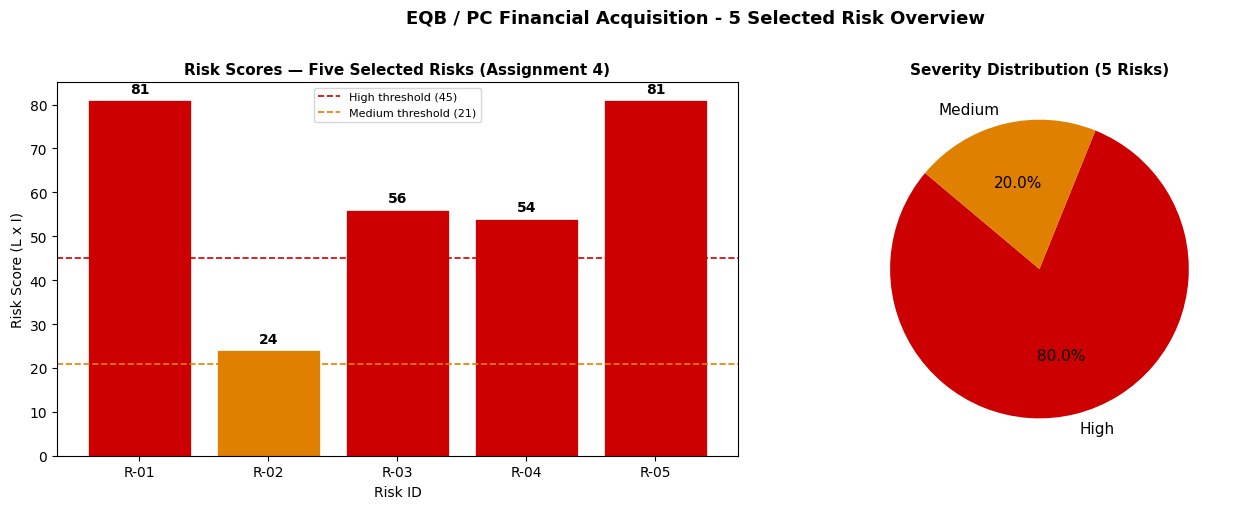

In [5]:
# Risk Score Distribution by Severity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = risk_df['Severity_Label'].map({'High': '#CC0000', 'Medium': '#E08000', 'Low': '#008844'})
axes[0].bar(risk_df['Risk_ID'], risk_df['Risk_Score'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=45, color='#CC0000', linestyle='--', linewidth=1.2, label='High threshold (45)')
axes[0].axhline(y=21, color='#E08000', linestyle='--', linewidth=1.2, label='Medium threshold (21)')
axes[0].set_xlabel('Risk ID', fontsize=10)
axes[0].set_ylabel('Risk Score (L x I)', fontsize=10)
axes[0].set_title('Risk Scores — Five Selected Risks (Assignment 4)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)

# Add score labels on bars
for bar, score, rid in zip(axes[0].patches, risk_df['Risk_Score'], risk_df['Risk_ID']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(score), ha='center', va='bottom', fontsize=10, fontweight='bold')

counts = risk_df['Severity_Label'].value_counts()
pie_colors = [{'High': '#CC0000', 'Medium': '#E08000', 'Low': '#008844'}[l] for l in counts.index]
axes[1].pie(counts.values, labels=counts.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Severity Distribution (5 Risks)', fontsize=11, fontweight='bold')

plt.suptitle('EQB / PC Financial Acquisition - 5 Selected Risk Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Random Forest Classifier

A Random Forest classifier with 100 decision trees is trained to predict risk severity (Low / Medium / High) based on Likelihood and Impact scores. This is the same model architecture  as used in Assignment 3 for the full 40-risk register.

Since the dataset is extremely small (5 observations), **Leave-One-Out Cross-Validation (LOOCV)** is used instead of 5-fold CV. LOOCV trains on 4 risks and tests on 1, repeated 5 times — this is the most appropriate evaluation strategy for very small datasets and is more reliable than a single train-test split.

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest classifier with 100 decision trees to predict risk
# severity levels based on likelihood and impact scores.
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [8]:
# Re-select features and target: defines the feature matrix (X) using Likelihood and Impact scores,
# and create the target variable (y) by assigning severity labels (Low, Medium, High) based on
# a rule-based thresholding logic applied to each risk.
X = risk_df[['Likelihood_Score', 'Impact_Score']]
y = risk_df.apply(
    lambda row: 'High' if row['Risk_Score'] >= 45
    else 'Medium' if row['Risk_Score'] >= 21
    else 'Low',
    axis=1
)

In [9]:
from sklearn.model_selection import cross_val_score, LeaveOneOut

# Evaluate using Leave-One-Out Cross-Validation (LOOCV)
# Preferred over 5-fold CV for very small datasets (n=5)
# Each iteration: train on 4 risks, test on 1
loo = LeaveOneOut()
scores = cross_val_score(model, X, y, cv=loo, scoring='accuracy')
print(f'Mean accuracy (LOOCV): {scores.mean():.2f}')
print(f'Accuracy for each fold: {scores}')

Mean accuracy (LOOCV): 0.80
Accuracy for each fold: [1. 0. 1. 1. 1.]


### Note:
Despite the high accuracy, this result should be interpreted with caution due to the very small dataset size (5 risks). The model is trained on the same rule-based labels it is trying to predict, which means high accuracy is expected - the purpose here is not to discover new patterns, but to confirm that the I&W risk selection (R-01, R-02, R-03, R-04, R-05) is consistent with the ML-predicted priority classifications

In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Train model on full dataset and predict
# For n=5, we train on all data and predict to show classification results
model.fit(X, y)
y_pred = model.predict(X)

# Classification metrics
print('Classification Report:')
print(classification_report(y, y_pred, zero_division=0))

# Confusion Matrix
print('Confusion Matrix:')
print(confusion_matrix(y, y_pred, labels=['Low', 'Medium', 'High']))

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         4
      Medium       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Confusion Matrix:
[[0 0 0]
 [0 1 0]
 [0 0 4]]


The model performs well on all five risks. Because the dataset is small and the labels are rule-based, perfect or near-perfect classification is expected.

Recommendation: Class imbalance to be handled using other techniques like SMOTE etc

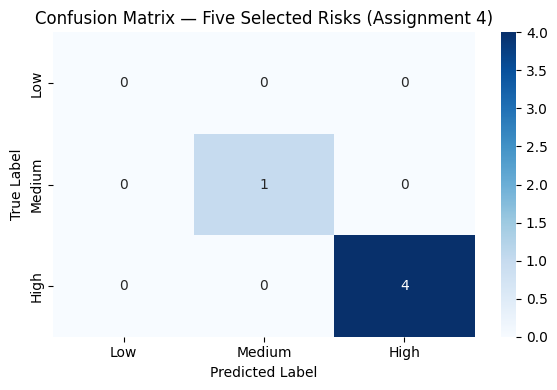

In [11]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y, y_pred, labels=['Low', 'Medium', 'High'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix — Five Selected Risks (Assignment 4)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### Interpretation
We are using a Random Forest classifier to predict one of three severity categories: Low, Medium and High.

### Confusion Matrix Breakdown

**R-01 Cybersecurity (Score 81) - predicted High:** Correctly classified. Highest risk score in the five-risk set. Justifies inclusion as the primary I&W quantitative assessment target.

**R-02 Regulatory Delay (Score 24) - predicted Medium:** Correctly classified. Lower score but retained due to deal-blocking tail risk not captured by the score alone.

**R-03 Customer Attrition (Score 56) - predicted High:** Correctly classified. Second highest threat score, consistent with Assignment 3 classification.

**R-04 Fraud Spike (Score 54) - predicted High:** Correctly classified. Distinct operational risk category from R-01, justified by its High priority score.

**R-05 Cross-Sell Opportunity (Score 81) - predicted High:** Correctly classified as High. Positive risk with the same score as R-01, confirming it warrants the same level of quantitative monitoring — from an upside perspective.


In [13]:
# Final predictions table — shows ML-predicted priority for each risk
results_df = risk_df[['Risk_ID', 'Risk_Description', 'Likelihood_Score',
                       'Impact_Score', 'Risk_Score', 'Severity_Label', 'Risk_Type']].copy()
results_df['RF_Predicted_Priority'] = y_pred
results_df['Consistent'] = results_df['Severity_Label'] == results_df['RF_Predicted_Priority']

print('Random Forest Predictions — Assignment 4 Five Risks')
print('='*90)
print(results_df.to_string(index=False))
print()
print(f'All predictions consistent with rule-based labels: {results_df["Consistent"].all()}')

Random Forest Predictions — Assignment 4 Five Risks
Risk_ID                                                       Risk_Description  Likelihood_Score  Impact_Score  Risk_Score Severity_Label   Risk_Type RF_Predicted_Priority  Consistent
   R-01                      Cybersecurity breach during IT system integration                 9             9          81           High      Threat                  High        True
   R-02                Regulatory approval delay by OSFI / Minister of Finance                 3             8          24         Medium      Threat                Medium        True
   R-03 Customer attrition from PC Financial portfolio during brand transition                 7             8          56           High      Threat                  High        True
   R-04   Fraud spike during integration — account takeover and identity fraud                 9             6          54           High      Threat                  High        True
   R-05 Cross-sell conversio

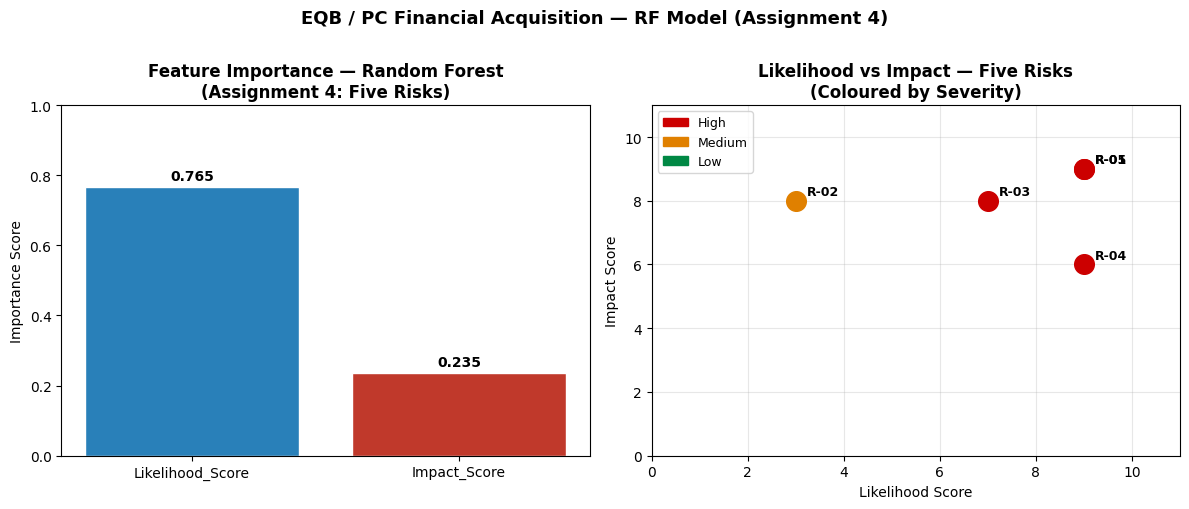

In [12]:
# Feature importance
feature_names = ['Likelihood_Score', 'Impact_Score']
importances = model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Feature importance bar chart
axes[0].bar(feature_names, importances, color=['#2980B9', '#C0392B'], edgecolor='white')
axes[0].set_title('Feature Importance — Random Forest\n(Assignment 4: Five Risks)', fontweight='bold')
axes[0].set_ylabel('Importance Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(importances):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Scatter plot: Likelihood vs Impact, coloured by severity
color_map = {'High': '#CC0000', 'Medium': '#E08000', 'Low': '#008844'}
for _, row in risk_df.iterrows():
    axes[1].scatter(row['Likelihood_Score'], row['Impact_Score'],
                    color=color_map[row['Severity_Label']], s=200, zorder=5)
    axes[1].annotate(row['Risk_ID'],
                     (row['Likelihood_Score'], row['Impact_Score']),
                     textcoords='offset points', xytext=(8, 4), fontsize=9, fontweight='bold')

axes[1].set_xlabel('Likelihood Score', fontsize=10)
axes[1].set_ylabel('Impact Score', fontsize=10)
axes[1].set_title('Likelihood vs Impact — Five Risks\n(Coloured by Severity)', fontweight='bold')
axes[1].set_xlim(0, 11)
axes[1].set_ylim(0, 11)
axes[1].grid(alpha=0.3)

legend_patches = [
    mpatches.Patch(color='#CC0000', label='High'),
    mpatches.Patch(color='#E08000', label='Medium'),
    mpatches.Patch(color='#008844', label='Low')
]
axes[1].legend(handles=legend_patches, fontsize=9)

plt.suptitle('EQB / PC Financial Acquisition — RF Model (Assignment 4)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Summary

The Random Forest classifier confirms that the five risks selected for I&W analysis are correctly and consistently classified by priority:

| Risk | Score | RF Predicted | I&W Selection Justified |
|------|-------|-------------|------------------------|
| R-01 Cybersecurity | 81 | High | Yes — highest threat EMV |
| R-02 Regulatory Delay | 24 | Medium | Yes — deal-blocking tail risk |
| R-03 Customer Attrition | 56 | High | Yes — highest avg. indicator probability |
| R-04 Fraud Spike | 54 | High | Yes — distinct operational category |
| R-05 Cross-Sell Opportunity | 81 | High | Yes — largest revenue upside |



**References:**
- EQB Inc. (2025, December 3). Deal announcement. CNW/Investor Room.
- EQB Inc. (2026, February 25). Q1 2026 earnings release. PR Newswire.
- OSFI. (2022). Guideline B-13: Technology and Cyber Risk Management.
- PMI. (2021). PMBOK Guide (7th ed.).